# Model
model.py

In [1]:
import torch
import torch.nn as nn
from typing import Tuple, List

class FinancialVAE(nn.Module):
    
    def __init__(
        self, 
        n_stock: int,
        window: int,
        hidden_dims: List[int] = [128, 64],
        dropout: float = 0.25,
        activation: str = 'elu'
    ):
        super(FinancialVAE, self).__init__()
        
        self.input_dim = n_stock * window + window
        self.window = window

        self.activation = self._get_activation(activation)
        self.hidden = self._build_hidden(hidden_dims, dropout)
        
        self.alpha_embedder = nn.Linear(hidden_dims[-1], n_stock)
        self.beta_embedder  = nn.Linear(hidden_dims[-1], n_stock)
    
    def _get_activation(self, activation: str) -> nn.Module:
        activations = {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'selu': nn.SELU(),
            'leaky_relu': nn.LeakyReLU(0.2)
        }
        return activations.get(activation.lower(), nn.ELU())
    
    def _build_hidden(self, hidden_dims: List[int], dropout: float) -> nn.Sequential:
        layers = []
        prev_dim = self.input_dim
        
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(self.activation)
            layers.append(nn.Dropout(dropout))
            prev_dim = h_dim
        
        return nn.Sequential(*layers)
    
    def forward(self, X: torch.Tensor, r_market: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        h = self.hidden(X)
        
        alpha = self.alpha_embedder(h)
        beta  = self.beta_embedder(h)

        r_market = r_market.unsqueeze(1)
        reconstruction = alpha + beta * r_market
        
        return reconstruction, alpha, beta

# Data
data.py

In [2]:
import torch
from torch.utils.data import Dataset

class SyntheticLogReturnsDataset(Dataset):
    def __init__(self, n_stock=None, t=None, window=None, distribution='normal', include_market=False, seed=42):
        self.n_stock = n_stock
        self.t = t
        self.window = window
        self.distribution = distribution
        self.include_market = include_market
        self.seed = seed
        
        if n_stock is not None and t is not None and window is not None:
            self._generate_data()
    
    def _generate_data(self):
        torch.manual_seed(self.seed)
        
        t_total = self.t + self.window - 1
        # SPY 20-year mean = 0.0003
        # SPY 20-year std  = 0.0122
        self.r_market = self._generate_returns(t_total, self.distribution, mean=0.0003, std=0.0122)
        self.alphas = torch.randn(self.n_stock) * 0.005
        self.betas = torch.randn(self.n_stock) * 0.3 + 1.0
        self.idio_vols = torch.rand(self.n_stock) * 0.015 + 0.005
        
        r_systematic = self.alphas.unsqueeze(1) + self.betas.unsqueeze(1) * self.r_market.unsqueeze(0)
        idio_noise = self._generate_returns((self.n_stock, t_total), self.distribution)
        idio_noise = idio_noise * self.idio_vols.unsqueeze(1)
        self.returns = r_systematic + idio_noise
        
        self._precompute_windows()
    
    def _generate_returns(self, shape, distribution, mean=0.0, std=1.0):
        if distribution == 'normal':
            return torch.randn(shape) * std + mean
        elif distribution == 't':
            dist = torch.distributions.studentT.StudentT(df=5.0)
            samples = dist.sample(shape if isinstance(shape, tuple) else (shape,))
            return samples * std / (5/3)**0.5 + mean
        else:
            raise ValueError(f"Unknown distribution: {distribution}")
    
    def _precompute_windows(self):
        windows = []
        for i in range(self.t):
            stock_windows = []
            for stock_idx in range(self.n_stock):
                stock_window = self.returns[stock_idx, i:i+self.window]
                stock_windows.append(stock_window)
            
            stock_data = torch.cat(stock_windows)
            
            if self.include_market:
                market_window = self.r_market[i:i+self.window]
                window_data = torch.cat([stock_data, market_window])
            else:
                window_data = stock_data
            
            windows.append(window_data)
        
        self.windowed_data = torch.stack(windows)
    
    def __len__(self):
        return self.t
    
    def __getitem__(self, idx):
        if isinstance(idx, slice):
            indices = range(*idx.indices(len(self)))
            X = self.windowed_data[list(indices)]
        else:
            X = self.windowed_data[idx]

        start = self.window - 1
        end   = -self.window
        step  = self.window
        
        y = X[start:end:step]
        
        r_market = X[-1]

        return X, y, r_market
    
    def partition_stocks(self, n_partitions):
        """Partition dataset into subsets by stock while sharing the same market returns."""
        stocks_per_partition = self.n_stock // n_partitions
        partitions = []
        
        for i in range(n_partitions):
            start_stock = i * stocks_per_partition
            end_stock = start_stock + stocks_per_partition if i < n_partitions - 1 else self.n_stock
            
            partition = SyntheticLogReturnsDataset()
            partition.n_stock = end_stock - start_stock
            partition.t = self.t
            partition.window = self.window
            partition.distribution = self.distribution
            partition.include_market = self.include_market
            partition.seed = self.seed
            
            partition.r_market = self.r_market
            partition.alphas = self.alphas[start_stock:end_stock]
            partition.betas = self.betas[start_stock:end_stock]
            partition.idio_vols = self.idio_vols[start_stock:end_stock]
            partition.returns = self.returns[start_stock:end_stock]
            
            partition._precompute_windows()
            partitions.append(partition)
        
        return partitions

In [117]:
dataset = SyntheticLogReturnsDataset(
        n_stock=100,
        t=1000, 
        window=5, 
        distribution='normal',
        include_market=True,
        seed=42
    )

In [124]:
dataset[0][2].shape

torch.Size([])

# Main
main.py

In [3]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

#from data import SyntheticLogReturnsDataset
#from model import FinancialVAE

In [146]:
def config2str(config: dict):
    config_str = ""
    for key in config:
        config_str += f"{key:>20s}: {config[key]}\n"
    
    return config_str

def run_model(config, log_dir='runs/tmp'):
    writer = SummaryWriter(log_dir=log_dir)
    writer.add_text('hparams', config2str(config))

In [4]:
config = {
    'DATASET_N_STOCK': 500,
    'MODEL_N_STOCK': 10,
    'T': 1000,
    'WINDOW': 30,
    'HIDDEN_DIMS': [128, 64],
    'BATCH_SIZE': 1,           # Modify?
    'NUM_EPOCHS': 5,
    'LEARNING_RATE': 1e-4,
    'SHUFFLE_BATCHES': True,
    'DATASET_SPLIT_RATIO': 0.8,
    'DROPOUT': 0.25,
    'PATIENCE': 5,
    'ACTIVATION': 'elu',
    'DISTRIBUTION': 'normal',
    'SEED': 45
}

dataset = SyntheticLogReturnsDataset(
    n_stock        = config['DATASET_N_STOCK'],
    t              = config['T'],
    window         = config['WINDOW'],
    distribution   = config['DISTRIBUTION'],
    include_market = True,
    seed           = config['SEED']
)

n_partitions = config['DATASET_N_STOCK'] // config['MODEL_N_STOCK']
ignore_last_partition = config['DATASET_N_STOCK'] % config['MODEL_N_STOCK'] != 0

partitions = dataset.partition_stocks(n_partitions)
if ignore_last_partition:
    partitions = partitions[:-1]
    n_partitions -= 1

split_idx = int(config['DATASET_SPLIT_RATIO'] * n_partitions)

train_loaders = [
    DataLoader(
        partition,
        batch_size = config['BATCH_SIZE'],
        shuffle    = config['SHUFFLE_BATCHES']
    ) for partition in partitions[:split_idx]
]

val_loaders = [
    DataLoader(
        partition,
        batch_size = config['BATCH_SIZE'],
        shuffle    = config['SHUFFLE_BATCHES']
    ) for partition in partitions[split_idx:]
]

model = FinancialVAE(
    n_stock = config['MODEL_N_STOCK'],
    window = config['WINDOW'],
    hidden_dims = config['HIDDEN_DIMS'],
    dropout = config['DROPOUT'],
    activation = config['ACTIVATION']
)

optimizer = torch.optim.Adam(model.parameters(), lr=config['LEARNING_RATE'])
loss_function = nn.MSELoss(reduction='mean')

train_loss = []
val_loss = []
start_time = time.time()
for epoch in range(1, config['NUM_EPOCHS'] + 1):
    print(f"Epoch {epoch}\n-------------------------------")

    for current, train_loader in enumerate(train_loaders):
        model.train()
        for X, y, r_market in train_loader:
            
            reconstruction, alpha, beta = model(X, r_market)
            
            loss = loss_function(reconstruction, y)
            
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
    
            train_loss.append(loss.item())
            
        print(f"loss: {loss:>7f}  [{current:>5d}/{len(train_loaders):>5d}]  t={time.time() - start_time}s")


    for val_loader in val_loaders:
        model.eval()
        with torch.no_grad():
            for X, y, r_market in val_loader:
                reconstruction, alpha, beta = model(X, r_market)
                loss = loss_function(reconstruction, y)
                val_loss.append(loss.item())
    
    print(f"Validation Error: \n Avg loss: {np.mean(val_loss[-len(val_loaders):]):>8f}  t={time.time() - start_time}s\n")
    
print("Done!")

Epoch 1
-------------------------------
loss: 0.000930  [    0/   40]  t=1.488534688949585s
loss: 0.000374  [    1/   40]  t=2.9515485763549805s
loss: 0.000069  [    2/   40]  t=4.432560920715332s
loss: 0.000140  [    3/   40]  t=5.896056652069092s
loss: 0.000171  [    4/   40]  t=7.350665807723999s
loss: 0.000053  [    5/   40]  t=8.832546472549438s
loss: 0.000082  [    6/   40]  t=10.3126540184021s
loss: 0.000093  [    7/   40]  t=11.811093807220459s
loss: 0.000114  [    8/   40]  t=13.313639879226685s
loss: 0.000101  [    9/   40]  t=14.788528680801392s
loss: 0.000093  [   10/   40]  t=16.23138451576233s
loss: 0.000041  [   11/   40]  t=17.64659309387207s
loss: 0.000039  [   12/   40]  t=19.05837082862854s
loss: 0.000053  [   13/   40]  t=20.46421504020691s
loss: 0.000045  [   14/   40]  t=21.871304750442505s
loss: 0.000057  [   15/   40]  t=23.276780366897583s
loss: 0.000037  [   16/   40]  t=24.69609022140503s
loss: 0.000022  [   17/   40]  t=26.1306312084198s
loss: 0.000025  [   

# Benchmark
OLS

In [64]:
from scipy import stats

start_idx = config['WINDOW'] - 1
r = dataset.returns[:, start_idx:]
r_market = dataset.r_market[start_idx:]

ols = [stats.linregress(r_market, r[i]) for i in range(len(r))]
ols_alpha = torch.Tensor([ols_i.intercept for ols_i in ols])
ols_beta = torch.Tensor([ols_i.slope for ols_i in ols])

ols_reconstruction = ols_alpha.unsqueeze(1) + ols_beta.unsqueeze(1) @ r_market.unsqueeze(0)

ols_loss = loss_function(ols_reconstruction, r)

tensor(0.0002)

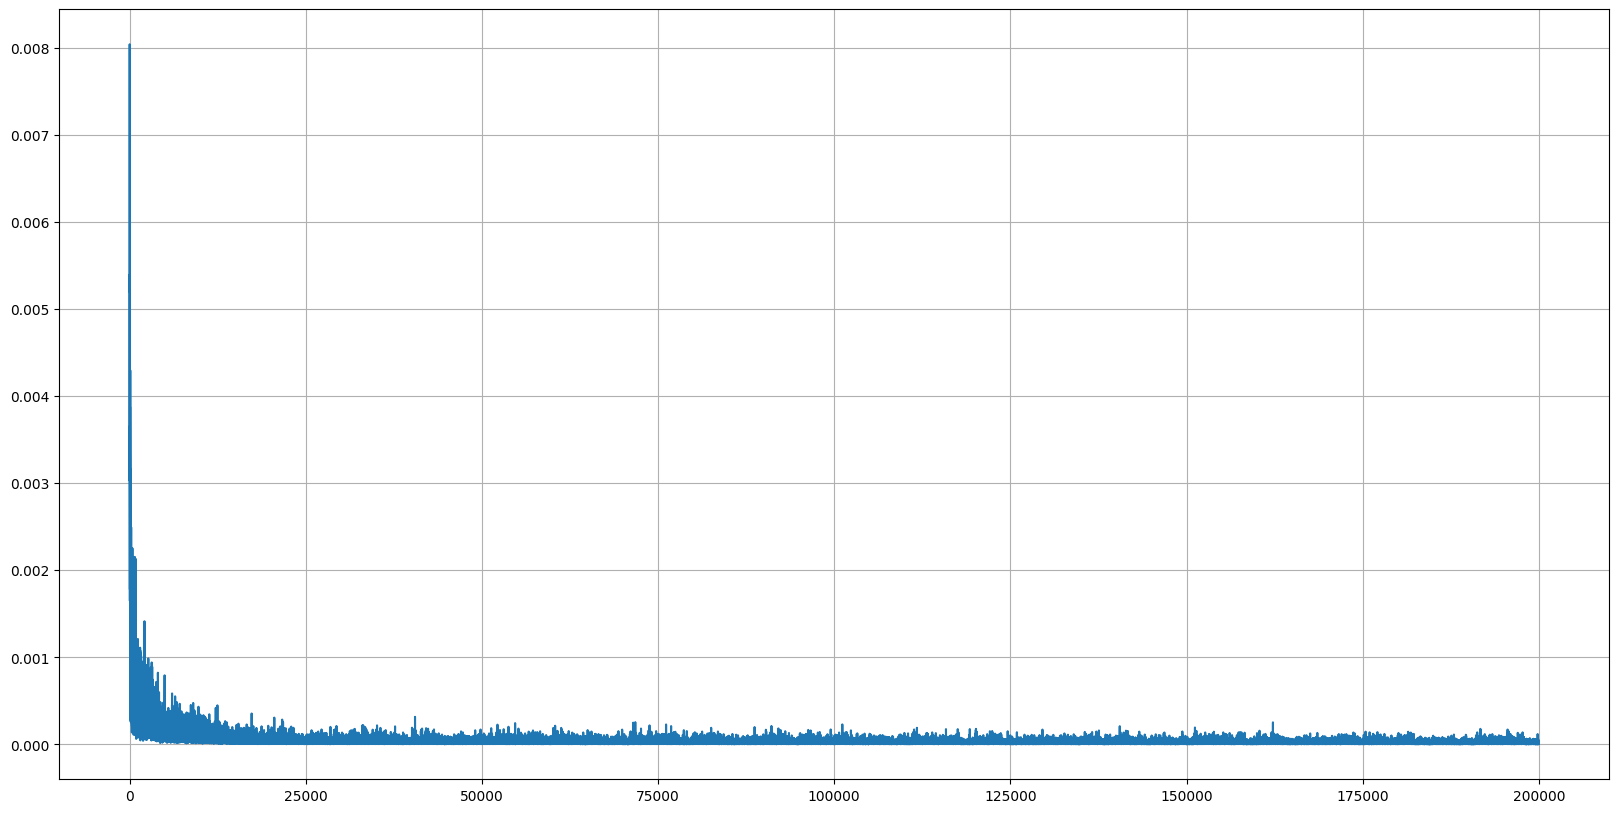

In [67]:
plt.figure(figsize=(20, 10))
plt.plot(train_loss)
plt.grid()
plt.show()

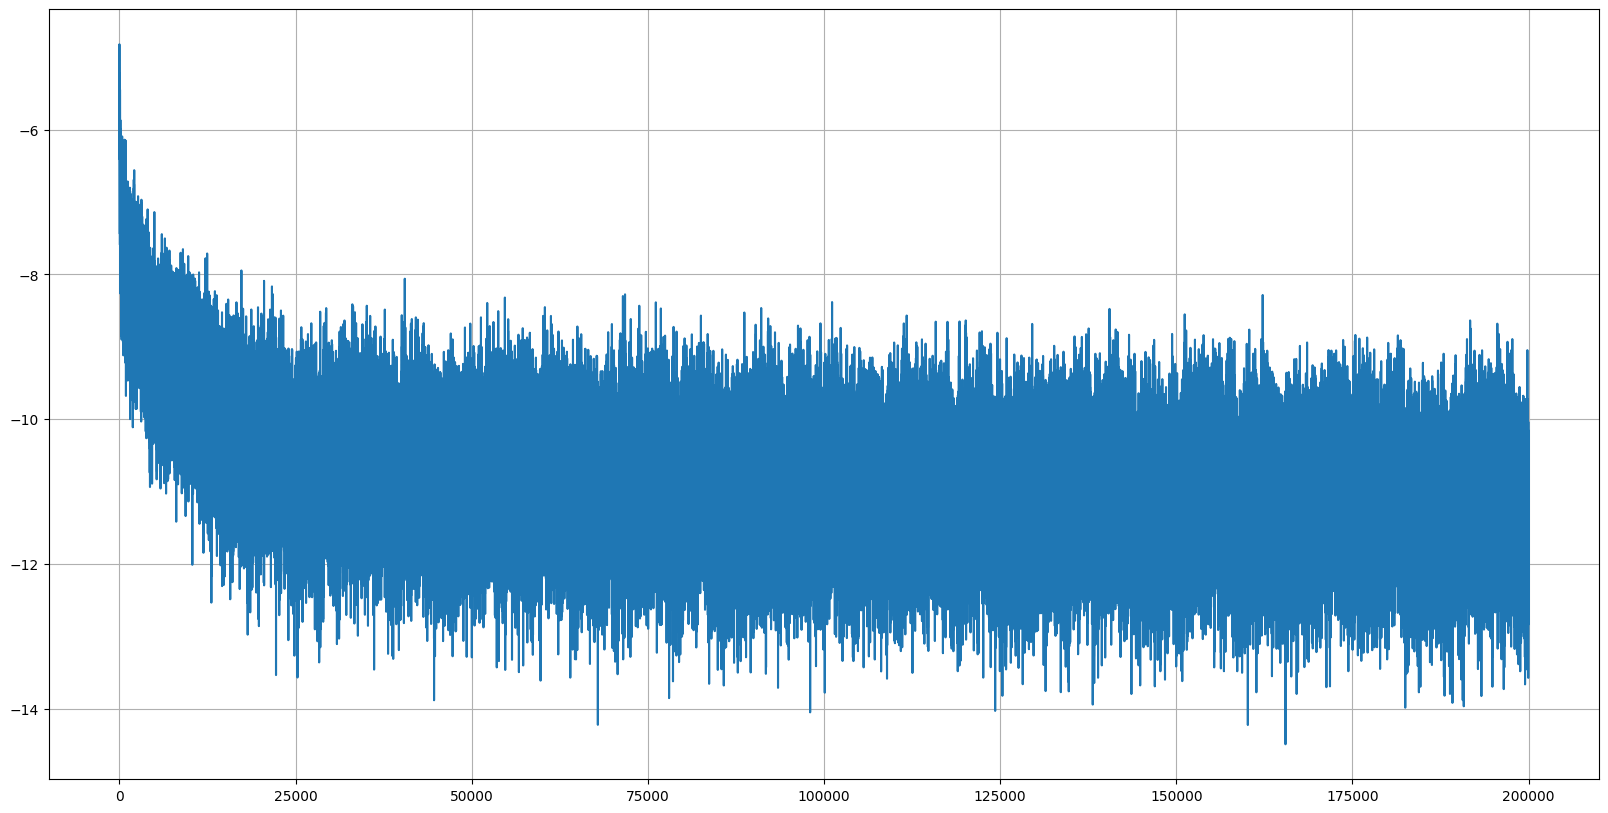

In [68]:
plt.figure(figsize=(20, 10))
plt.plot(np.log(train_loss))
plt.grid()
plt.show()

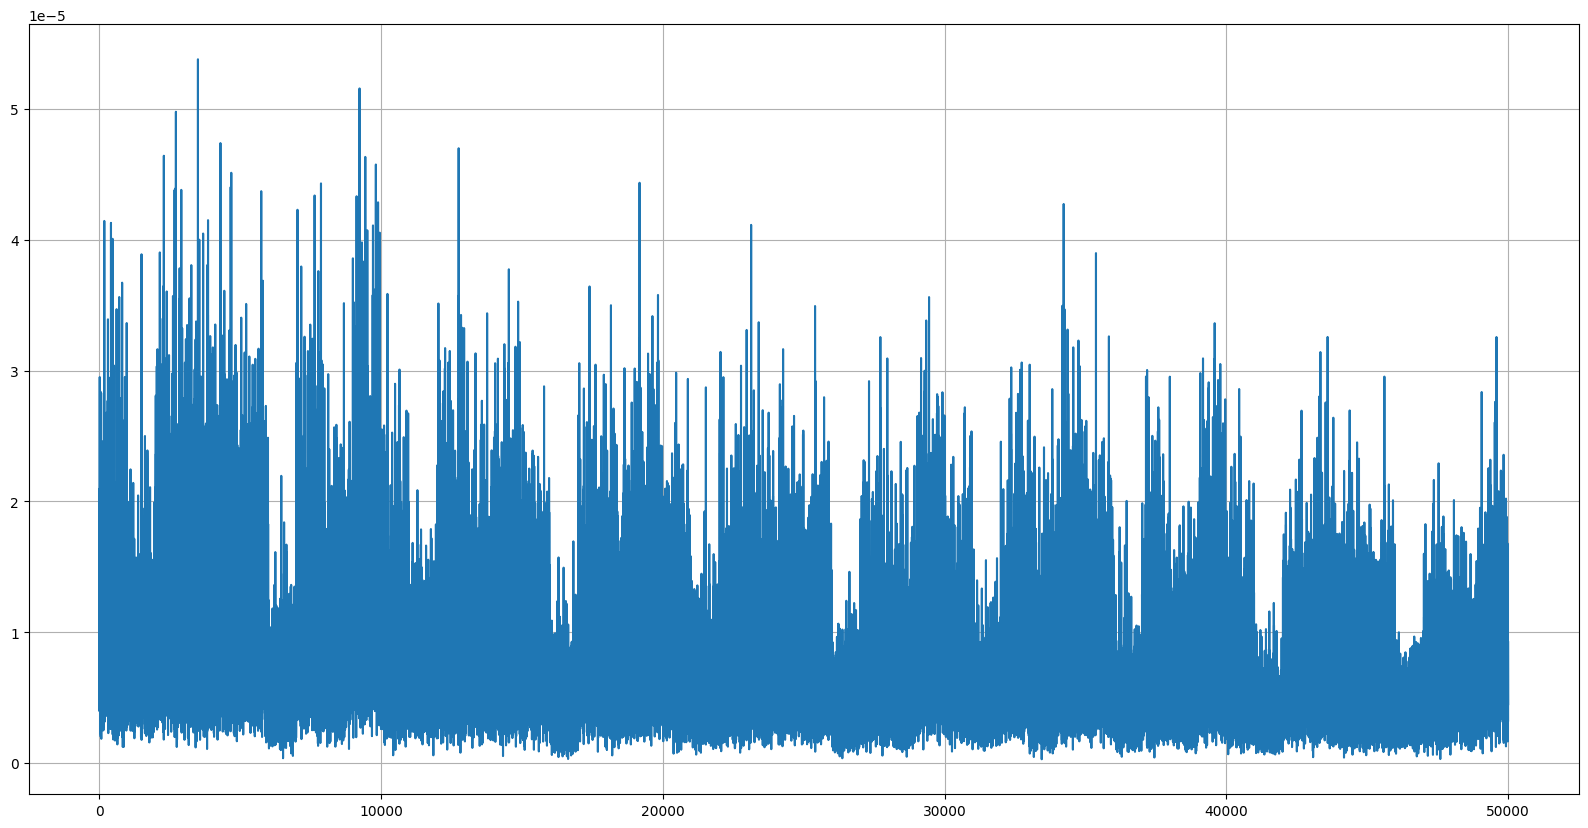

In [13]:
plt.figure(figsize=(20, 10))
plt.plot(val_loss)
plt.grid()
plt.show()

In [17]:
model

FinancialVAE(
  (activation): ELU(alpha=1.0)
  (hidden): Sequential(
    (0): Linear(in_features=330, out_features=128, bias=True)
    (1): ELU(alpha=1.0)
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ELU(alpha=1.0)
    (5): Dropout(p=0.25, inplace=False)
  )
  (alpha_embedder): Linear(in_features=64, out_features=10, bias=True)
  (beta_embedder): Linear(in_features=64, out_features=10, bias=True)
)

In [ ]:
X, y, r_market = dataset[0]

recon, a, b = model(X, r_market)

print(y)
print(recon)

In [126]:
def main():
    
    config = {
        'N_STOCK': 300,
        'T': 250,
        'WINDOW': 3,
        'HIDDEN_DIMS': [128, 64],
        'LATENT_DIM': 1,
        'BATCH_SIZE': 1,
        'NUM_EPOCHS': 30,
        'LEARNING_RATE': 1e-4,
        'SHUFFLE_BATCHES': True,
        'DATASET_SPLIT_RATIO': 0.8,
        'DROPOUT': 0.25,
        'PATIENCE': 5,
        'ACTIVATION': 'elu'
    }
    
    ts = [200, 500, 1000, 2000]
    windows = [1, 2 ,3, 5]
    
    for window in windows:
        for t in ts:
            config['T'] = t
            config['WINDOW'] = window

            print(f'Running model t={t}, window={window}')
            run_model(config, log_dir=f'runs/exp_t{t}_w{window}')

if __name__ == "__main__":
    #main()
    print('Remove comment')

Remove comment
